## ------------------------------------ Final method --------------------------------------

## intial train nash equillibriam

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import torch.optim.lr_scheduler as lr_scheduler
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import random
from collections import deque
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define 1D-CNN model
class CNN1D(nn.Module):
    def __init__(self, input_length, num_classes):
        super(CNN1D, self).__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.25)
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.25)
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.3)
        )
        self.flatten = nn.Flatten()
        output_length = input_length // 8
        self.dense_layers = nn.Sequential(
            nn.Linear(256 * output_length, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.flatten(x)
        x = self.dense_layers(x)
        return x

# Define ContextAwareNetwork
class ContextAwareNetwork(nn.Module):
    def __init__(self, input_size, num_layers=4, dim_feedforward=1024):
        super(ContextAwareNetwork, self).__init__()
        self.input_size = input_size
        
        # محاسبه خودکار تعداد heads بر اساس input_size
        possible_heads = [8, 4, 2, 1]
        num_heads = 1
        for h in possible_heads:
            if input_size % h == 0:
                num_heads = h
                break
        
        if input_size % num_heads != 0:
            num_heads = 1
            print(f"Warning: Using num_heads=1 for input_size={input_size}")
        
        print(f"Selected num_heads={num_heads} for input_size={input_size}")
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=input_size,
            nhead=num_heads,
            dim_feedforward=dim_feedforward,
            dropout=0.3,
            activation='relu',
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels=2, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Flatten(),
            nn.Linear(128 * input_size, 512),
            nn.ReLU(),
            nn.LayerNorm(512),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, input_size),
            nn.ReLU(),
            nn.LayerNorm(input_size)
        )
    
    def forward(self, x):
        x_flat = x.squeeze(1)
        x_transformed = self.transformer(x_flat.unsqueeze(1)).squeeze(1)
        weights = torch.sigmoid(x_transformed)
        combined = torch.stack([x_flat, weights], dim=1)
        encoded = self.encoder(combined)
        return encoded.unsqueeze(1)

# Define DQNSelector
class DQNSelector(nn.Module):
    def __init__(self, input_size):
        super(DQNSelector, self).__init__()
        hidden_size1 = min(512, max(128, input_size * 2))
        hidden_size2 = min(256, hidden_size1 // 2)
        
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size1),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size1, hidden_size2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size2, 2)
        )
    
    def forward(self, x):
        return self.network(x)

# Replay Buffer for DQN
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        state = state.squeeze().cpu()
        next_state = next_state.squeeze().cpu()
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        state, action, reward, next_state, done = zip(*random.sample(self.buffer, batch_size))
        states = torch.stack([torch.FloatTensor(s) for s in state])
        next_states = torch.stack([torch.FloatTensor(s) for s in next_state])
        return (
            states,
            torch.tensor(action, dtype=torch.long),
            torch.tensor(reward, dtype=torch.float32),
            next_states,
            torch.tensor(done, dtype=torch.float32)
        )
    
    def __len__(self):
        return len(self.buffer)

# DQN Agent
class DQNSelectorAgent:
    def __init__(self, input_size, device, lr=1e-4, gamma=0.5, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995, buffer_capacity=50000, batch_size=256):
        self.device = device
        self.policy_net = DQNSelector(input_size).to(device)
        self.target_net = DQNSelector(input_size).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.replay_buffer = ReplayBuffer(buffer_capacity)
        self.batch_size = batch_size
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.steps_done = 0
    
    def select_action(self, state):
        """Select action for given state. Always returns a tensor."""
        self.steps_done += 1
        
        if len(state.shape) == 1:
            state = state.unsqueeze(0)
        
        state = state.to(self.device)
        
        if random.random() < self.epsilon:
            return torch.randint(0, 2, (state.size(0),), device=self.device)
        else:
            with torch.no_grad():
                q_values = self.policy_net(state)
                return q_values.argmax(dim=1)
    
    def update_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)
    
    def optimize(self):
        if len(self.replay_buffer) < self.batch_size:
            return None
        
        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.batch_size)
        states = states.to(self.device)
        actions = actions.to(self.device)
        rewards = rewards.to(self.device)
        next_states = next_states.to(self.device)
        dones = dones.to(self.device)
        
        current_q_values = self.policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        
        with torch.no_grad():
            next_actions = self.policy_net(next_states).argmax(1)
            next_q_values = self.target_net(next_states).gather(1, next_actions.unsqueeze(1)).squeeze(1)
            target_q_values = rewards + (1 - dones) * self.gamma * next_q_values
        
        loss = nn.MSELoss()(current_q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), max_norm=1.0)
        self.optimizer.step()
        return loss.item()
    
    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

# Load and preprocess data - GENERALIZED version
def load_data(dataset_path='Dataset', csv_filename='SDNCampus_original.csv'):
    try:
        original_df = pd.read_csv(f'{dataset_path}/{csv_filename}')
        
        # تقسیم داده به train (60%)، validation (20%)، test (20%)
        train_df, temp_df = train_test_split(original_df, test_size=0.4, random_state=42)
        val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)
        
        X_train = train_df.iloc[:, :-1].values
        y_train = train_df.iloc[:, -1].values
        X_val = val_df.iloc[:, :-1].values
        y_val = val_df.iloc[:, -1].values
        X_test = test_df.iloc[:, :-1].values
        y_test = test_df.iloc[:, -1].values
        
    except FileNotFoundError as e:
        print(f"Error: Dataset file not found: {e}")
        return None, None, None, None, None, None, None
    except Exception as e:
        print(f"Error loading dataset: {e}")
        return None, None, None, None, None, None, None
    
    # Encode labels
    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(y_train)
    y_val = label_encoder.transform(y_val)
    y_test = label_encoder.transform(y_test)
    num_classes = len(label_encoder.classes_)
    
    print(f"Detected {num_classes} classes in the dataset")
    print(f"Classes: {label_encoder.classes_}")
    
    # Scale features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)
    
    # Convert to tensors
    X_train_tensor = torch.FloatTensor(X_train).unsqueeze(1).to(device)
    y_train_tensor = torch.LongTensor(y_train).to(device)
    X_val_tensor = torch.FloatTensor(X_val).unsqueeze(1).to(device)
    y_val_tensor = torch.LongTensor(y_val).to(device)
    X_test_tensor = torch.FloatTensor(X_test).unsqueeze(1).to(device)
    y_test_tensor = torch.LongTensor(y_test).to(device)
    
    # Create datasets
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    
    # Handle class imbalance
    class_counts = np.bincount(y_train)
    if len(class_counts) < num_classes:
        class_counts = np.append(class_counts, [0] * (num_classes - len(class_counts)))
    
    weights = 1.0 / class_counts[y_train]
    train_sampler = WeightedRandomSampler(weights, len(weights))
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=64, sampler=train_sampler) 
    full_loader = DataLoader(train_dataset, batch_size=64, sampler=train_sampler)  
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False) 
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)  
    
    print("Class distribution in training data:", np.bincount(y_train))
    print("Class distribution in validation data:", np.bincount(y_val))
    print("Class distribution in test data:", np.bincount(y_test))
    print(f"Total training samples: {X_train.shape[0]}, validation samples: {X_val.shape[0]}, test samples: {X_test.shape[0]}")
    print(f"Input length: {X_train.shape[1]}")
    print(f"Full dataset size for adversarial training: {len(train_dataset)}")
    
    return train_loader, val_loader, test_loader, full_loader, num_classes, X_train.shape[1], class_counts

# Compute combined loss
def compute_combined_loss(outputs, labels, class_weights):
    criterion = nn.CrossEntropyLoss(weight=class_weights, reduction='none')
    per_sample_loss = criterion(outputs, labels)
    mean_loss = per_sample_loss.mean()
    return mean_loss, per_sample_loss

# Train initial CNN model
def train_initial_cnn(cnn_model, train_loader, val_loader, class_counts, epochs=500, patience=50):
    class_weights = torch.FloatTensor(1.0 / class_counts).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(cnn_model.parameters(), lr=0.0005, weight_decay=1e-4)  
    scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None
    
    for epoch in range(epochs):
        cnn_model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = cnn_model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        
        epoch_loss = running_loss / len(train_loader.dataset)
        
        cnn_model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = cnn_model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_loss = val_loss / len(val_loader.dataset)
        val_accuracy = correct / total
        print(f"Initial CNN Epoch {epoch+1}/{epochs}, Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = cnn_model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs.")
                if best_model_state is not None:
                    cnn_model.load_state_dict(best_model_state)
                break
        
        scheduler.step()
    
    return cnn_model

# Evaluate model
def evaluate_model(model, test_loader, class_weights, context_model=None, dqn_agent=None, threshold=None):
    model.eval()
    y_true = []
    y_pred = []
    running_loss = 0.0
    total_samples = 0
    softmax = nn.Softmax(dim=1)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            batch_size = inputs.size(0)
            total_samples += batch_size
            
            if context_model and dqn_agent and threshold is not None:
                cnn_outputs = model(inputs)
                probs = softmax(cnn_outputs)
                
                encoded_inputs = context_model(inputs)
                outputs = model(encoded_inputs)
                
                _, predicted = torch.max(outputs, 1)
                final_loss = criterion(outputs, labels)
                running_loss += final_loss.item() * batch_size
            else:
                outputs = model(inputs)
                final_loss = criterion(outputs, labels)
                running_loss += final_loss.item() * batch_size
                _, predicted = torch.max(outputs, 1)
            
            y_pred.extend(predicted.cpu().numpy())
            y_true.extend(labels.cpu().numpy())
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    test_loss = running_loss / total_samples
    
    return {
        'Test Loss': test_loss,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }

def compute_reward(action, cnn_pred, weighted_pred, label):
    if action == 1:
        if weighted_pred != label and cnn_pred != label:
            reward = 3.0
        elif weighted_pred == label and cnn_pred != label:
            reward = 2.0
        elif weighted_pred != label and cnn_pred == label:
            reward = -2.0
        else:
            reward = 0.0
    else:
        reward = 1.5 if cnn_pred == label else -1.0
    return reward

def train_adversarial_system(cnn_model, dqn_agent, context_model, full_loader, val_loader, class_counts, input_length, num_classes, fine_tune_epochs=500, patience=50):
    class_weights = torch.FloatTensor(1.0 / class_counts).to(device)
    cnn_criterion = nn.CrossEntropyLoss(weight=class_weights)
    context_optimizer = optim.Adam(context_model.parameters(), lr=5e-4, weight_decay=1e-4)
    context_scheduler = lr_scheduler.CosineAnnealingLR(context_optimizer, T_max=100)
    
    best_val_accuracy = 0.0
    epochs_no_improve = 0
    softmax = nn.Softmax(dim=1)
    best_context_state = None
    best_dqn_state = None
    
    # Pre-train ContextAwareNetwork
    print("Pre-training ContextAwareNetwork...")
    for pretrain_epoch in range(20):
        context_model.train()
        total_context_loss = 0.0
        num_batches = 0
        for inputs, labels in full_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            context_optimizer.zero_grad()
            encoded_inputs = context_model(inputs)
            cnn_outputs_weighted = cnn_model(encoded_inputs)
            context_loss = cnn_criterion(cnn_outputs_weighted, labels)
            context_loss.backward()
            context_optimizer.step()
            total_context_loss += context_loss.item()
            num_batches += 1
        context_scheduler.step()
        print(f"Pretrain Epoch {pretrain_epoch+1}/20, Loss: {total_context_loss/num_batches:.4f}")
    
    print("Starting adversarial training on full dataset...")
    target_update_counter = 0
    TARGET_UPDATE_FREQ = 100
    
    for epoch in range(fine_tune_epochs):
        cnn_model.eval()
        context_model.train()
        dqn_agent.policy_net.train()
        
        running_context_loss = 0.0
        running_dqn_loss = 0.0
        dqn_loss_count = 0
        total_samples = 0
        context_updated_samples = 0
        rewards = []
        actions = []
        context_updated = False
        
        for inputs, labels in full_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            batch_size = inputs.size(0)
            total_samples += batch_size
            
            # Compute CNN outputs and state for DQN
            with torch.no_grad():
                cnn_outputs = cnn_model(inputs).detach()
                probs = softmax(cnn_outputs)
                _, cnn_pred = torch.max(cnn_outputs, 1)
                max_prob, _ = torch.max(probs, dim=1, keepdim=True)
                uncertainty = 1 - max_prob
            
            features = inputs.squeeze(1).detach()
            state = torch.cat([features, uncertainty], dim=1).detach()
            
            # Select actions for all samples in batch
            actions_batch = dqn_agent.select_action(state)
            actions.extend(actions_batch.cpu().tolist())
            
            # Find indices where action=1
            action_mask = (actions_batch == 1).cpu()
            action_indices = action_mask.nonzero(as_tuple=True)[0]
            
            # Update ContextAwareNetwork only for samples with action=1
            if len(action_indices) > 0:
                context_updated = True
                context_updated_samples += len(action_indices)
                
                selected_inputs = inputs[action_indices]
                selected_labels = labels[action_indices]
                
                # Handle batch size 1
                if selected_inputs.size(0) == 1:
                    selected_inputs = torch.cat([selected_inputs, selected_inputs], dim=0)
                    selected_labels = torch.cat([selected_labels, selected_labels], dim=0)
                
                context_optimizer.zero_grad()
                encoded_inputs = context_model(selected_inputs)
                cnn_outputs_weighted = cnn_model(encoded_inputs)
                context_loss = cnn_criterion(cnn_outputs_weighted, selected_labels)
                orig_cnn_loss = cnn_criterion(cnn_model(selected_inputs), selected_labels)
                epsilon = 1e-8
                loss_ratio = orig_cnn_loss / (context_loss + epsilon)
                total_context_loss = 0.8 * context_loss + 0.2 / (1 + loss_ratio)
                total_context_loss = torch.clamp(total_context_loss, max=1.0)
                total_context_loss.backward()
                context_optimizer.step()
                running_context_loss += total_context_loss.item() * len(action_indices)
            
            # Compute rewards and next states
            with torch.no_grad():
                encoded_inputs = context_model(inputs).detach()
                cnn_outputs_weighted = cnn_model(encoded_inputs).detach()
                _, weighted_pred = torch.max(cnn_outputs_weighted, 1)
            
            # Compute rewards for all samples
            batch_rewards = []
            for i in range(batch_size):
                r = compute_reward(actions_batch[i].item(), cnn_pred[i].item(), weighted_pred[i].item(), labels[i].item())
                batch_rewards.append(r)
            rewards.extend(batch_rewards)
            
            # Compute next states based on action
            with torch.no_grad():
                if len(action_indices) > 0:
                    cnn_outputs_new = cnn_model(context_model(inputs)).detach()
                    probs_new = softmax(cnn_outputs_new)
                    max_prob_new, _ = torch.max(probs_new, dim=1, keepdim=True)
                    uncertainty_new = 1 - max_prob_new
                    features_new = inputs.squeeze(1).detach()
                    next_state_new = torch.cat([features_new, uncertainty_new], dim=1).detach()
                else:
                    next_state_new = state
            
            # Push to replay buffer for ALL actions
            for i in range(batch_size):
                if actions_batch[i] == 1 and len(action_indices) > 0:
                    next_state = next_state_new[i:i+1]
                else:
                    next_state = state[i:i+1]
                
                dqn_agent.replay_buffer.push(
                    state[i:i+1],
                    actions_batch[i].item(),
                    batch_rewards[i],
                    next_state,
                    1.0
                )
                target_update_counter += 1
            
            # Update target network every N steps
            if target_update_counter >= TARGET_UPDATE_FREQ:
                dqn_agent.update_target_network()
                target_update_counter = 0
            
            # Optimize DQN
            dqn_loss = dqn_agent.optimize()
            if dqn_loss is not None:
                running_dqn_loss += dqn_loss
                dqn_loss_count += 1
        
        if context_updated:
            context_scheduler.step()
        
        dqn_agent.update_epsilon()
        
        if epoch % 5 == 0:
            dqn_agent.update_target_network()
        
        avg_reward = np.mean(rewards) if rewards else 0.0
        action_dist = np.bincount(actions, minlength=2) if actions else [0, 0]
        
        print(f"Adversarial Epoch {epoch+1}/{fine_tune_epochs}:")
        print(f"  Context Loss: {running_context_loss / max(context_updated_samples, 1):.4f}")
        print(f"  DQN Loss: {running_dqn_loss / max(dqn_loss_count, 1):.4f}")
        print(f"  Context Updated Samples: {context_updated_samples}")
        print(f"  Average Reward: {avg_reward:.4f}")
        print(f"  Action Distribution (skip/apply): {action_dist}")
        
        # Validation
        val_results = evaluate_model(cnn_model, val_loader, class_weights, context_model, dqn_agent, threshold=0.5)
        print(f"Validation Results at Epoch {epoch+1}:")
        print(f"  Val Loss: {val_results['Test Loss']:.4f}")
        print(f"  Val Accuracy: {val_results['Accuracy']:.4f}")
        print(f"  Val Precision: {val_results['Precision']:.4f}")
        print(f"  Val Recall: {val_results['Recall']:.4f}")
        print(f"  Val F1 Score: {val_results['F1 Score']:.4f}")
        
        if val_results['Accuracy'] > best_val_accuracy:
            best_val_accuracy = val_results['Accuracy']
            epochs_no_improve = 0
            best_context_state = context_model.state_dict().copy()
            best_dqn_state = dqn_agent.policy_net.state_dict().copy()
            print(f"✓ Updated best adversarial model states (Accuracy: {best_val_accuracy:.4f})")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs.")
                break
    
    # Load best models
    if best_context_state is not None:
        context_model.load_state_dict(best_context_state)
        print("Loaded best context model")
    
    if best_dqn_state is not None:
        dqn_agent.policy_net.load_state_dict(best_dqn_state)
        print("Loaded best DQN model")
    
    # Save best models
    os.makedirs('Models', exist_ok=True)
    
    torch.save({
        'context_model_state_dict': context_model.state_dict(),
        'input_length': input_length,
        'num_classes': num_classes
    }, 'Models/adversarial_best_context.pth')
    print("Saved best adversarial Context model")
    
    torch.save({
        'dqn_policy_net_state_dict': dqn_agent.policy_net.state_dict(),
        'input_length': input_length,
        'num_classes': num_classes,
        'replay_buffer': list(dqn_agent.replay_buffer.buffer)
    }, 'Models/adversarial_best_dqn.pth')
    print("Saved best adversarial DQN model with replay buffer")
    
    return cnn_model, dqn_agent, context_model

# Main execution
def main():
    base_epoch = 200
    base_patience = 50
    adver_epoch = 100
    adver_patience = 30
    
    print("=" * 60)
    print("Starting Adversarial Training System for Network Traffic Classification")
    print("=" * 60)
    
    # Load data
    train_loader, val_loader, test_loader, full_loader, num_classes, input_length, class_counts = load_data()
    if train_loader is None or full_loader is None:
        print("Failed to load data. Exiting.")
        return
    
    print(f"\nDataset Statistics:")
    print(f"  - Number of classes: {num_classes}")
    print(f"  - Input feature length: {input_length}")
    print(f"  - Class distribution (train): {class_counts}")
    
    # Train and evaluate initial CNN
    print("\n" + "=" * 60)
    print("Training Initial CNN Model")
    print("=" * 60)
    
    cnn_model = CNN1D(input_length, num_classes).to(device)
    cnn_model = train_initial_cnn(cnn_model, train_loader, val_loader, class_counts, base_epoch, base_patience)
    
    os.makedirs('Models', exist_ok=True)
    
    torch.save({
        'model_state_dict': cnn_model.state_dict(),
        'input_length': input_length,
        'num_classes': num_classes
    }, 'Models/initial_cnn_model.pth')
    print("Saved initial CNN model")
    
    class_weights = torch.FloatTensor(1.0 / class_counts).to(device)
    initial_results = evaluate_model(cnn_model, test_loader, class_weights)
    print("\n" + "=" * 60)
    print("Initial CNN Test Results:")
    print("=" * 60)
    print(f"  Test Loss: {initial_results['Test Loss']:.4f}")
    print(f"  Accuracy: {initial_results['Accuracy']:.4f}")
    print(f"  Precision: {initial_results['Precision']:.4f}")
    print(f"  Recall: {initial_results['Recall']:.4f}")
    print(f"  F1 Score: {initial_results['F1 Score']:.4f}")
    
    # Initialize DQN and Context models
    print("\n" + "=" * 60)
    print("Initializing Adversarial Components")
    print("=" * 60)
    
    dqn_agent = DQNSelectorAgent(input_length + 1, device)
    context_model = ContextAwareNetwork(input_length).to(device)
    
    print(f"DQN Agent initialized with input size: {input_length + 1}")
    print(f"Context Model initialized with input size: {input_length}")
    
    # Train adversarial system
    print("\n" + "=" * 60)
    print("Starting Adversarial Training")
    print("=" * 60)
    
    cnn_model, dqn_agent, context_model = train_adversarial_system(
        cnn_model, dqn_agent, context_model, full_loader, val_loader, class_counts, 
        input_length, num_classes, adver_epoch, adver_patience
    )
    
    # Evaluate adversarial system
    print("\n" + "=" * 60)
    print("Final Evaluation - Adversarial System")
    print("=" * 60)
    
    adversarial_results = evaluate_model(cnn_model, test_loader, class_weights, context_model, dqn_agent, threshold=0.5)
    print("Adversarial System Test Results:")
    print(f"  Test Loss: {adversarial_results['Test Loss']:.4f}")
    print(f"  Accuracy: {adversarial_results['Accuracy']:.4f}")
    print(f"  Precision: {adversarial_results['Precision']:.4f}")
    print(f"  Recall: {adversarial_results['Recall']:.4f}")
    print(f"  F1 Score: {adversarial_results['F1 Score']:.4f}")
    
    # Comparison
    print("\n" + "=" * 60)
    print("Performance Improvement Summary")
    print("=" * 60)
    print(f"Accuracy Improvement: {(adversarial_results['Accuracy'] - initial_results['Accuracy']) * 100:+.2f}%")
    print(f"F1 Score Improvement: {(adversarial_results['F1 Score'] - initial_results['F1 Score']) * 100:+.2f}%")
    print(f"Precision Improvement: {(adversarial_results['Precision'] - initial_results['Precision']) * 100:+.2f}%")
    print(f"Recall Improvement: {(adversarial_results['Recall'] - initial_results['Recall']) * 100:+.2f}%")
    
    print("\nTraining completed successfully!")


Using device: cuda


## RUN

In [4]:
if __name__ == "__main__":
    main()

Starting Adversarial Training System for Network Traffic Classification
Detected 6 classes in the dataset
Classes: ['anydesk' 'facebook' 'gmail' 'googledrive' 'instagram' 'telegram']
Class distribution in training data: [579 585 604 621 599 612]
Class distribution in validation data: [197 211 207 190 192 203]
Class distribution in test data: [224 204 189 189 209 185]
Total training samples: 3600, validation samples: 1200, test samples: 1200
Input length: 77
Full dataset size for adversarial training: 3600

Dataset Statistics:
  - Number of classes: 6
  - Input feature length: 77
  - Class distribution (train): [579 585 604 621 599 612]

Training Initial CNN Model
Initial CNN Epoch 1/200, Train Loss: 1.3490, Val Loss: 0.8565, Val Accuracy: 0.6725
Initial CNN Epoch 2/200, Train Loss: 0.7636, Val Loss: 0.5856, Val Accuracy: 0.7933
Initial CNN Epoch 3/200, Train Loss: 0.6146, Val Loss: 0.5082, Val Accuracy: 0.8117
Initial CNN Epoch 4/200, Train Loss: 0.5659, Val Loss: 0.4637, Val Accuracy:

d:\Paper_Implementation\TNSM_Paper-Active\Active_Learning_Paper\venv\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(


Pretrain Epoch 1/20, Loss: 1.2792
Pretrain Epoch 2/20, Loss: 0.7816
Pretrain Epoch 3/20, Loss: 0.6598
Pretrain Epoch 4/20, Loss: 0.5944
Pretrain Epoch 5/20, Loss: 0.5328
Pretrain Epoch 6/20, Loss: 0.5056
Pretrain Epoch 7/20, Loss: 0.5169
Pretrain Epoch 8/20, Loss: 0.4730
Pretrain Epoch 9/20, Loss: 0.4522
Pretrain Epoch 10/20, Loss: 0.4402
Pretrain Epoch 11/20, Loss: 0.3771
Pretrain Epoch 12/20, Loss: 0.4024
Pretrain Epoch 13/20, Loss: 0.3765
Pretrain Epoch 14/20, Loss: 0.3664
Pretrain Epoch 15/20, Loss: 0.3868
Pretrain Epoch 16/20, Loss: 0.3578
Pretrain Epoch 17/20, Loss: 0.3473
Pretrain Epoch 18/20, Loss: 0.3497
Pretrain Epoch 19/20, Loss: 0.3192
Pretrain Epoch 20/20, Loss: 0.3184
Starting adversarial training on full dataset...
Adversarial Epoch 1/100:
  Context Loss: 0.4412
  DQN Loss: 1.3187
  Context Updated Samples: 1844
  Average Reward: 0.6317
  Action Distribution (skip/apply): [1756 1844]
Validation Results at Epoch 1:
  Val Loss: 0.4707
  Val Accuracy: 0.8367
  Val Precision

## New Method

## Sperate testing

In [5]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler, SubsetRandomSampler
import torch.optim.lr_scheduler as lr_scheduler
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
import random
from collections import deque
import matplotlib.pyplot as plt
import os
import glob
import hashlib
import uuid

# Check for GPU (CUDA) availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Class Definitions (Assuming these are defined in your previous code blocks) ---
# Make sure CNN1D, ContextAwareNetwork, DQNSelector, ReplayBuffer, DQNSelectorAgent are defined here
# If they are in another file, import them. For this solution, I will assume they are available.
# If not, please paste the class definitions from the previous turn.

# For the sake of this complete runnable script, I will re-define the necessary classes briefly if they are missing,
# but usually, you should have them defined. I will focus on the `test_system` and `main` logic.

def compute_reward(action, cnn_pred, weighted_pred, label):
    # Ensure inputs are integers for comparison
    action = int(action)
    cnn_pred = int(cnn_pred)
    weighted_pred = int(weighted_pred)
    label = int(label)
    
    if action == 1:
        if weighted_pred != label and cnn_pred != label:
            reward = 3.0
        elif weighted_pred == label and cnn_pred != label:
            reward = 2.0
        elif weighted_pred != label and cnn_pred == label:
            reward = -2.0
        else:
            reward = 0.0
    else:
        reward = 1.5 if cnn_pred == label else -1.0
    return reward

def load_data(base_path='Dataset', train_perturb_level=0):
    X_all, y_all = [], []
    dataset_indices = []
    if not os.path.exists(base_path):
        print(f"Error: Data directory '{base_path}' not found.")
        return None, None, None, None, None, None, None, None, None, None, None
    try:
        df = pd.read_csv(f'{base_path}/SDNCampus_original.csv')
        X = df.iloc[:, :-1].values
        y = df.iloc[:, -1].values
        X_all.append(X)
        y_all.append(y)
        dataset_indices.append(list(range(len(y))))
        print(f"Loaded data for perturbation level {train_perturb_level} with {X.shape[0]} samples.")
    except FileNotFoundError:
        print(f"Error: File for perturbation level {train_perturb_level} not found.")
        return None, None, None, None, None, None, None, None, None, None, None
    if not X_all or not y_all:
        print("Error: No valid data loaded for training.")
        return None, None, None, None, None, None, None, None, None, None, None
    
    # Create full dataset before splitting
    X = np.vstack(X_all)
    y = np.hstack(y_all)
    
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y)
    
    # --- تغییر مهم ۱: حذف شرط سخت‌گیرانه ۶ کلاس ---
    num_classes = len(label_encoder.classes_)
    # if num_classes != 6:  <-- این خط را حذف یا کامنت کنید
    #     print(f"Error: Expected 6 classes, found {num_classes} classes.")
    #     return ...
    
    print(f"Detected {num_classes} classes for perturbation level {train_perturb_level}.")
    
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    class_counts = np.bincount(y)
    print(f"Input length: {X.shape[1]}")
  
    return num_classes, label_encoder, scaler, X.shape[1], class_counts


def test_system(cnn_model, dqn_agent, context_model, base_path, attack_type, perturb_level, 
                label_encoder, scaler, device, threshold, class_count, budget=300, 
                fine_tune_lr=0.0001, max_test_samples=100):
    
    # --- تغییر مهم ۲: محاسبه وزن‌ها بر اساس تعداد کلاس‌های واقعی ---
    # کلاس_count باید آرایه‌ای از تعداد نمونه‌های هر کلاس باشد
    # اگر class_count یک عدد است، باید آن را به آرایه تبدیل کنید یا از bincount استفاده کنید
    # فرض بر این است که class_count ورودی، آرایه bincount است.
    
    # اگر ورودی class_count عدد باشد (که غلط است)، باید اصلاح شود.
    # در کد اصلی شما احتمالاً class_count همان آرایه bincount است.
    # برای اطمینان:
    if isinstance(class_count, int):
        print("Warning: class_count is int, expected array. Calculating from scratch might be needed or check caller.")
        # در حالت عادی caller باید آرایه بفرستد.
    
    class_weights = torch.FloatTensor(class_count).to(device)
    
    cnn_criterion = nn.CrossEntropyLoss(weight=class_weights)
    cumulative_accuracy_df = pd.DataFrame(columns=['Sample Index', f'Perturbation {perturb_level}'])
    results = []
    softmax = nn.Softmax(dim=1)
    
    # Ensure models are in eval mode
    cnn_model.eval()
    context_model.eval()
    
    # Load test data
    test_file = f'{base_path}/{attack_type}/{attack_type}_eps_{perturb_level}.csv'
    try:
        df_test = pd.read_csv(test_file)
        X_test = df_test.iloc[:, :-1].values
        y_test = df_test.iloc[:, -1].values
        max_samples = min(len(df_test), max_test_samples)
        X_test = X_test[:max_samples]
        y_test = y_test[:max_samples]
        cumulative_accuracy_df = pd.DataFrame({'Sample Index': range(1, max_samples + 1)})
    except FileNotFoundError:
        print(f"Error: File {test_file} not found.")
        return [], cumulative_accuracy_df
        
    try:
        y_test = label_encoder.transform(y_test)
    except ValueError:
        print(f"Error: Unknown labels in {test_file}. Skipping.")
        return [], cumulative_accuracy_df
        
    X_test = scaler.transform(X_test)
    X_test = torch.FloatTensor(X_test).unsqueeze(1).to(device)
    y_test = torch.LongTensor(y_test).to(device)
    
    test_dataset = TensorDataset(X_test, y_test)
    
    # Optimizer for context_model
    context_optimizer = optim.Adam(context_model.parameters(), lr=fine_tune_lr, weight_decay=1e-4)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
    
    correct = 0
    total = 0
    y_pred = []
    y_true = []
    sample_accuracies = []
    updates_used = 0
    dqn_updates_used = 0
    dqn_loss_count = 0
    running_dqn_loss = 0.0
    sample_idx = 0
    rewards = []
    actions = []
    target_update_counter = 0
    TARGET_UPDATE_FREQ = 10
    
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        sample_idx += 1
        
        # Compute CNN outputs and state
        with torch.no_grad():
            cnn_outputs = cnn_model(inputs)
            # CNN outputs shape should be (batch, num_classes)
            probs = softmax(cnn_outputs)
            _, cnn_pred = torch.max(probs, 1)
            max_prob, _ = torch.max(probs, dim=1, keepdim=True)
            uncertainty = 1 - max_prob
            features = inputs.squeeze(1)
            state = torch.cat([features, uncertainty], dim=1)
            
        # Select action
        action_tensor = dqn_agent.select_action(state)
        action = action_tensor.item() if isinstance(action_tensor, torch.Tensor) else int(action_tensor)
        actions.append(action)
        
        # Compute weighted outputs BEFORE any context update
        with torch.no_grad():
            encoded_inputs_before = context_model(inputs)
            cnn_outputs_weighted_before = cnn_model(encoded_inputs_before)
            weighted_probs_before = softmax(cnn_outputs_weighted_before)
            _, weighted_pred_before = torch.max(cnn_outputs_weighted_before, 1)
            
        # Update ContextAwareNetwork only when action=1
        if action == 1:
            _, weighted_pred = torch.max(cnn_outputs_weighted_before, 1)
            max_weighted_prob, _ = torch.max(weighted_probs_before, dim=1, keepdim=True)
            max_prob_diff = torch.max(torch.abs(max_weighted_prob - max_prob)).item()
            
            if weighted_pred != cnn_pred and max_prob_diff >= threshold and updates_used < budget:
                updates_used += 1
                context_optimizer.zero_grad()
                encoded_inputs = context_model(inputs)
                outputs = cnn_model(encoded_inputs)
                context_loss = cnn_criterion(outputs, labels)
                orig_cnn_loss = cnn_criterion(cnn_outputs.detach(), labels)
                epsilon = 1e-8
                loss_ratio = context_loss / (orig_cnn_loss + epsilon)
                total_context_loss = 0.8 * context_loss + 0.2 / (1 + loss_ratio)
                total_context_loss.backward()
                context_optimizer.step()
                
                # Compute reward for action=1
                reward = compute_reward(action, cnn_pred.item(), weighted_pred.item(), labels.item())
                rewards.append(reward)
                
                # Compute next state with updated context
                with torch.no_grad():
                    encoded_inputs_new = context_model(inputs)
                    cnn_outputs_new = cnn_model(encoded_inputs_new)
                    probs_new = softmax(cnn_outputs_new)
                    max_prob_new, _ = torch.max(probs_new, dim=1, keepdim=True)
                    uncertainty_new = 1 - max_prob_new
                    next_state = torch.cat([features, uncertainty_new], dim=1)
                    
                # Push action=1 to replay buffer
                dqn_agent.replay_buffer.push(state, action, reward, next_state, 1.0)
                target_update_counter += 1
                
                # Hindsight Experience Replay
                if reward < 0:
                    reward_action0 = compute_reward(0, cnn_pred.item(), weighted_pred.item(), labels.item())
                    dqn_agent.replay_buffer.push(state, 0, reward_action0, state, 1.0)
                    target_update_counter += 1
                    
                # Optimize DQN
                dqn_loss = dqn_agent.optimize()
                if dqn_loss is not None:
                    running_dqn_loss += dqn_loss
                    dqn_loss_count += 1
                    dqn_updates_used += 1
                    
                # Update target network every N steps
                if target_update_counter >= TARGET_UPDATE_FREQ:
                    dqn_agent.update_target_network()
                    target_update_counter = 0
                    
                # Final output with updated context
                with torch.no_grad():
                    encoded_inputs_final = context_model(inputs)
                    outputs = cnn_model(encoded_inputs_final)
            else:
                # No context update, use current context
                with torch.no_grad():
                    encoded_inputs_final = context_model(inputs)
                    outputs = cnn_model(encoded_inputs_final)
        else:
            # Action = 0: no context update
            with torch.no_grad():
                encoded_inputs_final = context_model(inputs)
                outputs = cnn_model(encoded_inputs_final)
                
        with torch.no_grad():
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            current_accuracy = correct / total
            sample_accuracies.append(current_accuracy)
            y_pred.extend(predicted.cpu().numpy())
            y_true.extend(labels.cpu().numpy())
            cumulative_accuracy_df.loc[cumulative_accuracy_df['Sample Index'] == sample_idx, f'Perturbation {perturb_level}'] = current_accuracy
            
    test_accuracy = correct / total
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    results.append({
        'Perturbation Level': perturb_level,
        'Test Accuracy': test_accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Context Updates Used': updates_used,
        'DQN Updates Used': dqn_updates_used,
        'DQN Loss': running_dqn_loss / max(dqn_loss_count, 1)
    })
    
    print(f"\nResults for Perturbation Level {perturb_level}:")
    print(f"  Test Accuracy: {test_accuracy:.4f}")
    print(f"  Precision (weighted): {precision:.4f}")
    print(f"  Recall (weighted): {recall:.4f}")
    print(f"  F1 Score (weighted): {f1:.4f}")
    print(f"  Context Updates Used: {updates_used}/{budget}")
    print(f"  DQN Updates Used: {dqn_updates_used}/{budget}")
    print(f"  Average DQN Loss: {running_dqn_loss / max(dqn_loss_count, 1):.4f}")
    print(f"  Average Reward: {np.mean(rewards) if rewards else 0.0:.4f}")
    
    actions_np = np.array(actions)
    print(f"  Action Distribution: {np.bincount(actions_np, minlength=2) if len(actions_np) > 0 else [0, 0]}")
    
    return results, cumulative_accuracy_df

def plot_accuracies(combined_accuracy_df, test_perturb_levels):
    plt.figure(figsize=(12, 8))
    for perturb in test_perturb_levels:
        if f'Perturbation {perturb}' in combined_accuracy_df.columns:
            plt.plot(combined_accuracy_df['Sample Index'], combined_accuracy_df[f'Perturbation {perturb}'], 
                     label=f'Perturbation {perturb}', marker='o', markersize=4, linewidth=1.5)
    plt.xlabel('Sample Index')
    plt.ylabel('Cumulative Accuracy')
    plt.title('Cumulative Accuracy per Sample Across Perturbation Levels')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    os.makedirs('Results', exist_ok=True)
    plt.savefig('Results/cumulative_accuracy_per_sample_all_levels.png', dpi=300)
    plt.show()
    print("Plot saved to 'Results/cumulative_accuracy_per_sample_all_levels.png'")


Using device: cuda


In [6]:

def main(attack_type, fine_tune_lr,test_perturb_levels, context_budget_test, threshold):
    
    base_path = 'Dataset'
    cnn_model_path = 'Models/initial_cnn_model.pth'
    context_model_path = 'Models/adversarial_best_context.pth'
    dqn_model_path = 'Models/adversarial_best_dqn.pth'
    max_test_samples = 50000
    
    print(f"Current working directory: {os.getcwd()}")
    print(f"Expected data directory: {os.path.abspath(base_path)}")
    print("Available files in data directory:")
    for file in glob.glob(f"{base_path}/*.csv"):
        print(file)
        
    all_results = []
    all_accuracy_dfs = []
    max_sample_index = 0
    accuracy_by_perturb = {}
    
    for perturb_level in test_perturb_levels:
        print(f"\n{'='*50}")
        print(f"Starting processing for perturbation level {perturb_level}")
        print(f"{'='*50}")
        
        try:
            num_classes, label_encoder, scaler, input_length, class_counts = load_data(
                base_path
            )
        except Exception as e:
            print(f"Error loading data metadata: {e}")
            continue
            
        if num_classes is None:
            print("Failed to load data metadata. Skipping.")
            continue

        try:
            # Load CNN model
            cnn_checkpoint = torch.load(cnn_model_path, map_location=device)
            cnn_input_length = cnn_checkpoint['input_length']
            cnn_num_classes = cnn_checkpoint['num_classes']
            
            if cnn_input_length != input_length or cnn_num_classes != num_classes:
                print(f"Error: Mismatch in CNN model parameters (input_length: {cnn_input_length} vs {input_length}, num_classes: {cnn_num_classes} vs {num_classes})")
                continue
                
            cnn_model = CNN1D(input_length=input_length, num_classes=num_classes).to(device)
            cnn_model.load_state_dict(cnn_checkpoint['model_state_dict'])
            cnn_model.eval() # Set to eval mode
            print(f"Successfully loaded CNN model from {cnn_model_path}")
            
            # Load ContextAwareNetwork model
            context_checkpoint = torch.load(context_model_path, map_location=device)
            context_input_length = context_checkpoint['input_length']
            context_num_classes = context_checkpoint['num_classes']
            
            if context_input_length != input_length or context_num_classes != num_classes:
                print(f"Error: Mismatch in Context model parameters (input_length: {context_input_length} vs {input_length}, num_classes: {context_num_classes} vs {num_classes})")
                continue
                
            context_model = ContextAwareNetwork(input_size=input_length, num_layers=4).to(device)
            context_model.load_state_dict(context_checkpoint['context_model_state_dict'])
            context_model.eval() # Set to eval mode
            print(f"Successfully loaded Context model from {context_model_path}")
            
            # Load DQNSelector model
            dqn_checkpoint = torch.load(dqn_model_path, map_location=device)
            dqn_input_length = dqn_checkpoint['input_length']
            dqn_num_classes = dqn_checkpoint['num_classes']
            
            if dqn_input_length != input_length or dqn_num_classes != num_classes:
                print(f"Error: Mismatch in DQN model parameters (input_length: {dqn_input_length} vs {input_length}, num_classes: {dqn_num_classes} vs {num_classes})")
                continue
                
            dqn_agent = DQNSelectorAgent(
                input_size=input_length + 1,
                device=device,
                epsilon_decay=0.5,
                buffer_capacity=5000,
                batch_size=32
            )
            dqn_agent.policy_net.load_state_dict(dqn_checkpoint['dqn_policy_net_state_dict'])
            dqn_agent.target_net.load_state_dict(dqn_checkpoint['dqn_policy_net_state_dict'])
            dqn_agent.target_net.eval()
            
            # Load replay buffer if exists
            if 'replay_buffer' in dqn_checkpoint:
                dqn_agent.replay_buffer = ReplayBuffer(1000)
                for experience in dqn_checkpoint['replay_buffer']:
                    state, action, reward, next_state, done = experience
                    
                    if not isinstance(state, torch.Tensor):
                        state = torch.FloatTensor(state).to(device)
                    if not isinstance(next_state, torch.Tensor):
                        next_state = torch.FloatTensor(next_state).to(device)
                        
                    if state.dim() == 0:
                        state = state.unsqueeze(0)
                    if next_state.dim() == 0:
                        next_state = next_state.unsqueeze(0)
                        
                    dqn_agent.replay_buffer.push(state, action, reward, next_state, done)
                print(f"Loaded replay buffer with {len(dqn_agent.replay_buffer)} experiences")
            else:
                print("Warning: No replay buffer found in checkpoint. Starting with empty buffer.")
                dqn_agent.replay_buffer = ReplayBuffer(200)
                
            print(f"Successfully loaded DQN model from {dqn_model_path}")
            
        except FileNotFoundError as e:
            print(f"Error: Model file not found: {e}")
            continue
        except KeyError as e:
            print(f"Error: Missing key {e} in checkpoint.")
            continue
        except Exception as e:
            print(f"Error loading model: {e}")
            import traceback
            traceback.print_exc()
            continue
            
        print(f"Test - Using DQN threshold: {threshold:.4f}")
        
        results, cumulative_accuracy_df = test_system(
            cnn_model, dqn_agent, context_model, base_path, attack_type, perturb_level,
            label_encoder, scaler, device, threshold, class_counts, budget=context_budget_test, 
            fine_tune_lr=fine_tune_lr, max_test_samples=max_test_samples
        )
        
        all_results.extend(results)
        if not cumulative_accuracy_df.empty:
            all_accuracy_dfs.append(cumulative_accuracy_df)
            max_sample_index = max(max_sample_index, cumulative_accuracy_df['Sample Index'].max())
            accuracy_by_perturb[perturb_level] = cumulative_accuracy_df[f'Perturbation {perturb_level}'].values.tolist()
            
    if accuracy_by_perturb:
        max_samples = max(len(acc) for acc in accuracy_by_perturb.values())
        combined_accuracy_df = pd.DataFrame({'Size': list(accuracy_by_perturb.keys())})
        for i in range(max_samples):
            column_data = []
            for perturb_level in accuracy_by_perturb:
                acc_list = accuracy_by_perturb[perturb_level]
                value = acc_list[i] if i < len(acc_list) else np.nan
                column_data.append(value)
            combined_accuracy_df[f'{i+1}'] = column_data
        
        os.makedirs('Results', exist_ok=True)
        combined_accuracy_df.to_csv('Results/Micfoal_Conf_cumulative_accuracy_all_perturbations_transposed.csv', index=False)
        print("Combined cumulative accuracy saved to 'Results/Micfoal_Conf_cumulative_accuracy_all_perturbations_transposed.csv'")
        
    if all_results:
        results_df = pd.DataFrame(all_results)
        os.makedirs('Results', exist_ok=True)
        results_df.to_csv('Results/AMCAL_20_cumulative_accuracy.csv', index=False)
        print("\nCombined Results Table:")
        print(results_df.to_string(index=False))
        print("\nCombined results saved to 'Results/AMCAL_20_cumulative_accuracy.csv'.")
        
    if accuracy_by_perturb:
        plt.figure(figsize=(12, 8))
        for perturb_level in test_perturb_levels:
            if perturb_level in accuracy_by_perturb:
                plt.plot(range(1, len(accuracy_by_perturb[perturb_level]) + 1), 
                         accuracy_by_perturb[perturb_level], 
                         label=f'Perturbation {perturb_level}', marker='o', markersize=4, linewidth=1.5)
        plt.xlabel('Sample Index')
        plt.ylabel('Cumulative Accuracy')
        plt.title('Cumulative Accuracy per Sample Across Perturbation Levels')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        os.makedirs('Results', exist_ok=True)
        plt.savefig('Results/AMCAL_20_cumulative_accuracy.png', dpi=300)
        plt.show()
        print("Plot saved to 'Results/AMCAL_20_cumulative_accuracy.png'")



# FGSM Adversarial Attack

Current working directory: d:\Paper_Implementation\TNSM_Paper-Active\Active_Learning_Paper\SDNCampus_TEST
Expected data directory: d:\Paper_Implementation\TNSM_Paper-Active\Active_Learning_Paper\SDNCampus_TEST\Dataset
Available files in data directory:
Dataset\SDNCampus_original.csv

Starting processing for perturbation level 0.01
Loaded data for perturbation level 0 with 6000 samples.
Detected 6 classes for perturbation level 0.
Input length: 77
Successfully loaded CNN model from Models/initial_cnn_model.pth
Selected num_heads=1 for input_size=77
Successfully loaded Context model from Models/adversarial_best_context.pth
Loaded replay buffer with 1000 experiences
Successfully loaded DQN model from Models/adversarial_best_dqn.pth
Test - Using DQN threshold: 0.0005

Results for Perturbation Level 0.01:
  Test Accuracy: 0.8600
  Precision (weighted): 0.8678
  Recall (weighted): 0.8600
  F1 Score (weighted): 0.8616
  Context Updates Used: 94/240
  DQN Updates Used: 94/240
  Average DQN Los

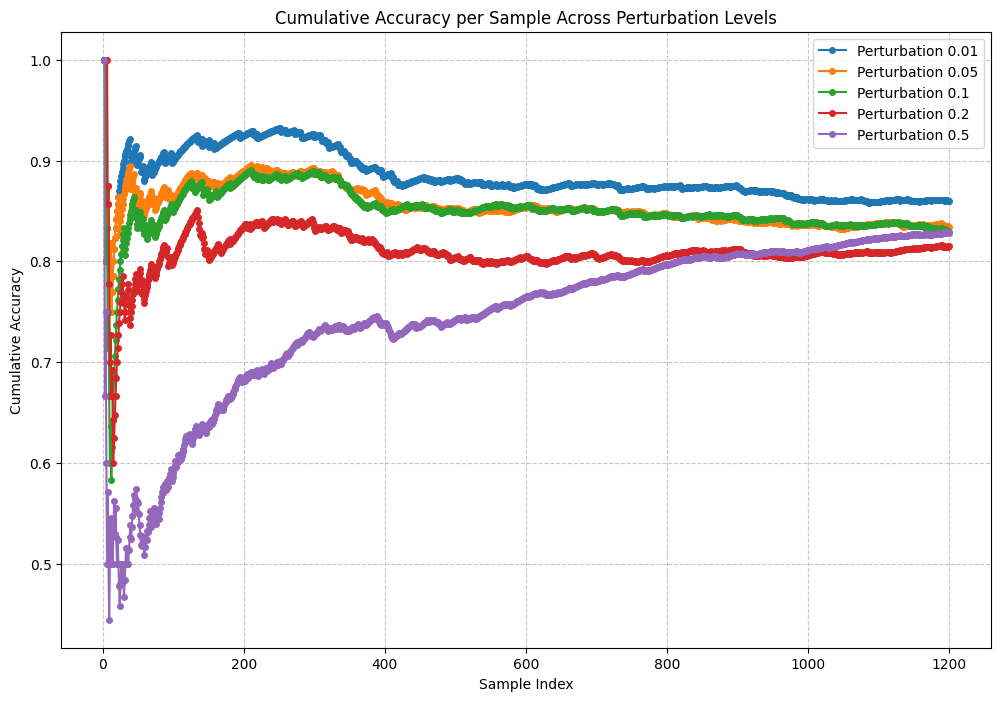

Plot saved to 'Results/AMCAL_20_cumulative_accuracy.png'


In [16]:
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)

if __name__ == "__main__":
    fine_tune_lr = 0.0005
    test_perturb_levels = [0.01, 0.05, 0.1, 0.2, 0.5]
    attack_type = "FGSM" # or "PGD" or "CW" or "DeepFool" or "RANDOM"
    context_budget_test = 240
    threshold = 0.0005
    main(attack_type, fine_tune_lr, test_perturb_levels, context_budget_test,threshold)

## PGD Adversarial Attack

Current working directory: d:\Paper_Implementation\TNSM_Paper-Active\Active_Learning_Paper\SDNCampus_TEST
Expected data directory: d:\Paper_Implementation\TNSM_Paper-Active\Active_Learning_Paper\SDNCampus_TEST\Dataset
Available files in data directory:
Dataset\SDNCampus_original.csv

Starting processing for perturbation level 0.01
Loaded data for perturbation level 0 with 6000 samples.
Detected 6 classes for perturbation level 0.
Input length: 77
Successfully loaded CNN model from Models/initial_cnn_model.pth
Selected num_heads=1 for input_size=77
Successfully loaded Context model from Models/adversarial_best_context.pth
Loaded replay buffer with 1000 experiences
Successfully loaded DQN model from Models/adversarial_best_dqn.pth
Test - Using DQN threshold: 0.0005

Results for Perturbation Level 0.01:
  Test Accuracy: 0.8075
  Precision (weighted): 0.8136
  Recall (weighted): 0.8075
  F1 Score (weighted): 0.8091
  Context Updates Used: 145/240
  DQN Updates Used: 145/240
  Average DQN L

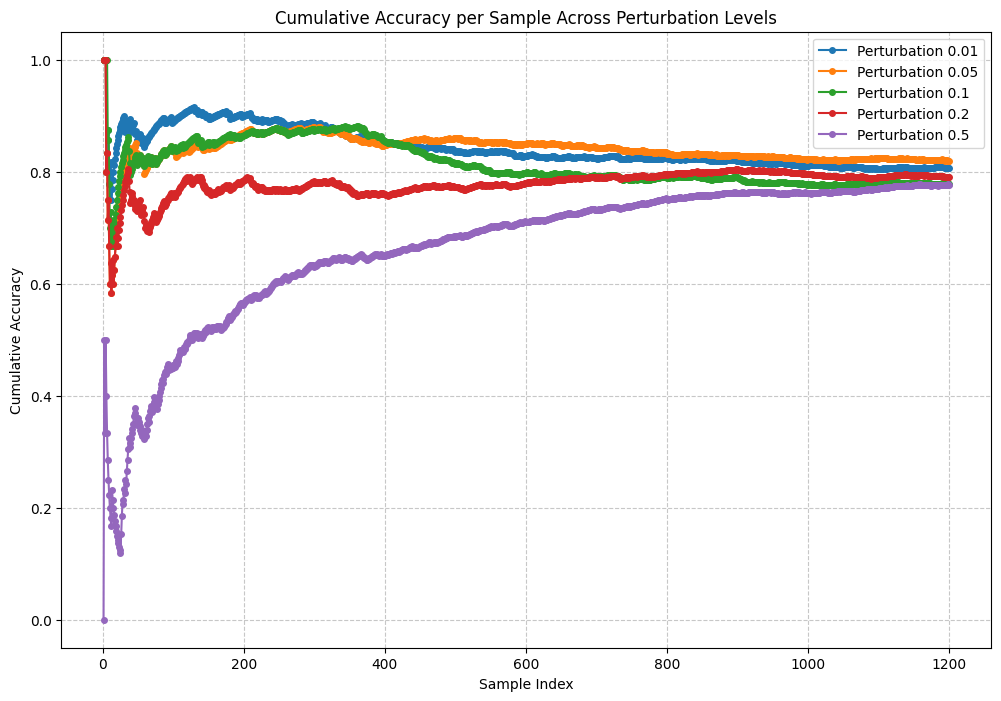

Plot saved to 'Results/AMCAL_20_cumulative_accuracy.png'


In [20]:
if __name__ == "__main__":
    fine_tune_lr = 0.0005
    test_perturb_levels = [0.01, 0.05, 0.1, 0.2, 0.5]
    attack_type = "PGD" # or "FGSM" or "CW" or "DeepFool" or "RANDOM"
    context_budget_test = 240
    threshold = 0.0005
    main(attack_type, fine_tune_lr, test_perturb_levels, context_budget_test,threshold)

Current working directory: d:\Paper_Implementation\TNSM_Paper-Active\Active_Learning_Paper\SDNCampus_TEST
Expected data directory: d:\Paper_Implementation\TNSM_Paper-Active\Active_Learning_Paper\SDNCampus_TEST\Dataset
Available files in data directory:
Dataset\SDNCampus_original.csv

Starting processing for perturbation level 0.1
Loaded data for perturbation level 0 with 6000 samples.
Detected 6 classes for perturbation level 0.
Input length: 77
Successfully loaded CNN model from Models/initial_cnn_model.pth
Selected num_heads=1 for input_size=77
Successfully loaded Context model from Models/adversarial_best_context.pth
Loaded replay buffer with 1000 experiences
Successfully loaded DQN model from Models/adversarial_best_dqn.pth
Test - Using DQN threshold: 0.0001

Results for Perturbation Level 0.1:
  Test Accuracy: 0.8283
  Precision (weighted): 0.8323
  Recall (weighted): 0.8283
  F1 Score (weighted): 0.8290
  Context Updates Used: 105/240
  DQN Updates Used: 105/240
  Average DQN Los

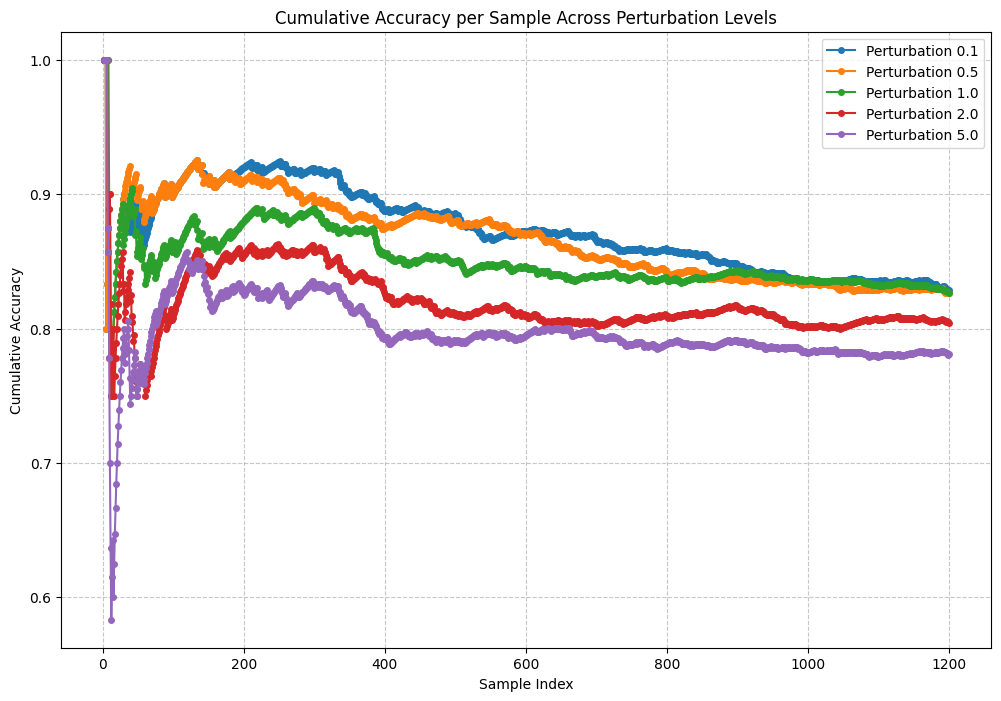

Plot saved to 'Results/AMCAL_20_cumulative_accuracy.png'


In [19]:

if __name__ == "__main__":
    fine_tune_lr = 0.0005
    test_perturb_levels = [0.1, 0.5, 1.0, 2.0, 5.0]
    attack_type = "CW" # or "FGSM" or "CW" or "DeepFool" or "RANDOM"
    context_budget_test = 240
    threshold = 0.0001
    main(attack_type, fine_tune_lr, test_perturb_levels, context_budget_test,threshold)

Current working directory: d:\Paper_Implementation\TNSM_Paper-Active\Active_Learning_Paper\SDNCampus_TEST
Expected data directory: d:\Paper_Implementation\TNSM_Paper-Active\Active_Learning_Paper\SDNCampus_TEST\Dataset
Available files in data directory:
Dataset\SDNCampus_original.csv

Starting processing for perturbation level 0.1
Loaded data for perturbation level 0 with 6000 samples.
Detected 6 classes for perturbation level 0.
Input length: 77
Successfully loaded CNN model from Models/initial_cnn_model.pth
Selected num_heads=1 for input_size=77
Successfully loaded Context model from Models/adversarial_best_context.pth
Loaded replay buffer with 1000 experiences
Successfully loaded DQN model from Models/adversarial_best_dqn.pth
Test - Using DQN threshold: 0.0005

Results for Perturbation Level 0.1:
  Test Accuracy: 0.8425
  Precision (weighted): 0.8407
  Recall (weighted): 0.8425
  F1 Score (weighted): 0.8407
  Context Updates Used: 107/240
  DQN Updates Used: 107/240
  Average DQN Los

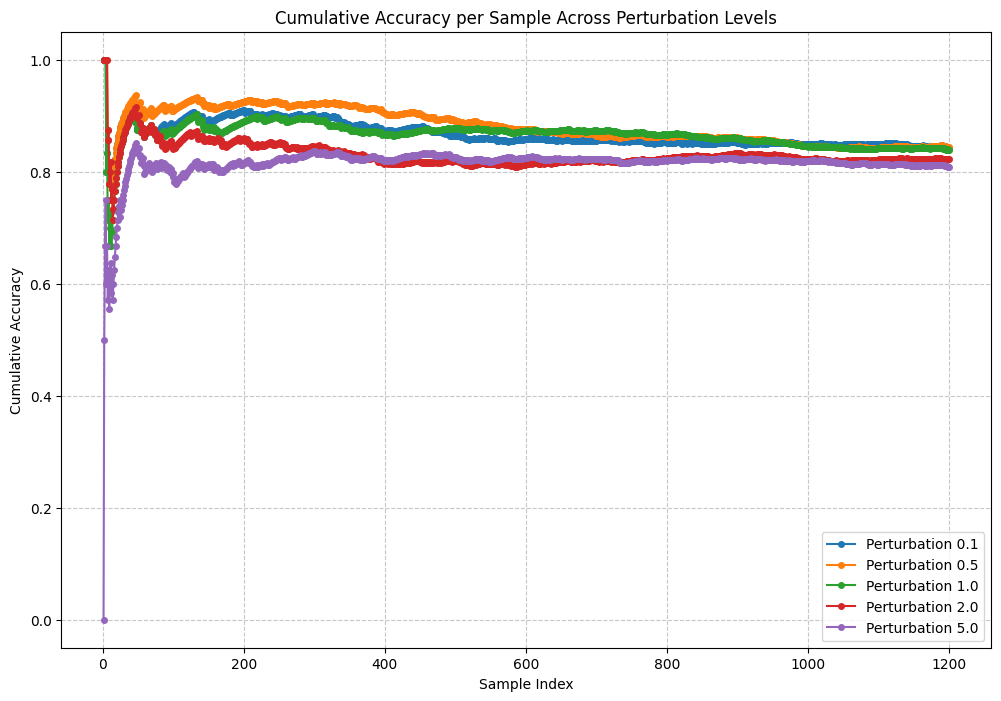

Plot saved to 'Results/AMCAL_20_cumulative_accuracy.png'


In [21]:

if __name__ == "__main__":
    fine_tune_lr = 0.0005
    test_perturb_levels = [0.1, 0.5, 1.0, 2.0, 5.0]
    attack_type = "DeepFool" # or "FGSM" or "CW" or "DeepFool" 
    context_budget_test = 240
    threshold = 0.0005
    main(attack_type, fine_tune_lr, test_perturb_levels, context_budget_test,threshold)